# Câncer de Mama

### Importacao de bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregar a base e visualizar primeiras linhas
df1 = pd.read_csv('BreastCancer.csv', index_col=0)
df1.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# dimnesões da base
df1.shape

(569, 31)

### Indicar a semente inicial e para divisão da base em treino e teste

In [4]:
np.random.seed(0)  # semente inicial para reprodução de resultados de split da base


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df1.loc[:, df1.columns != 'diagnosis'],  # input
                                                    df1.diagnosis,                           # output
                                                    test_size=0.3)

In [6]:
x_train.shape

(398, 30)

In [7]:
# alguns dados estatisticos por atributo
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,398.0,14.185500,3.598618,6.981000,11.710000,13.310000,15.772500,28.11000
texture_mean,398.0,19.192839,4.190476,9.710000,16.032500,18.725000,21.597500,33.81000
perimeter_mean,398.0,92.335503,24.769334,43.790000,75.310000,86.140000,104.475000,188.50000
area_mean,398.0,661.859045,366.558262,143.500000,420.350000,548.450000,779.125000,2501.00000
smoothness_mean,398.0,0.096475,0.013916,0.052630,0.086740,0.096035,0.105400,0.14470
compactness_mean,398.0,0.104080,0.051031,0.019380,0.066805,0.094035,0.128750,0.31140
concavity_mean,398.0,0.088794,0.078154,0.000000,0.030385,0.062650,0.128775,0.42680
concave points_mean,398.0,0.049479,0.039216,0.000000,0.020710,0.033870,0.075022,0.20120
symmetry_mean,398.0,0.180698,0.028057,0.106000,0.161525,0.179150,0.195400,0.30400
fractal_dimension_mean,398.0,0.062646,0.006861,0.049960,0.057685,0.061715,0.065735,0.09744


# Encoding Classe (LabelEncoder)
B = 0

M = 1

In [8]:
y_train.value_counts()

,count
diagnosis,
B,249
M,149


In [9]:
# Criar encoder para classe: categórico para numérico
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder = encoder.fit(y_train)

encoder.classes_

array(['B', 'M'], dtype=object)

In [10]:
# Como foi feito o encoding (em ordem alfabética)
encoder.transform(['B', 'M'])

array([0, 1])

In [11]:
antes_depois = pd.DataFrame()
antes_depois['antes'] = y_train

# aplicar encoder no treino e no teste
y_train = encoder.transform(y_train)
y_test = encoder.transform(y_test)

antes_depois['depois'] = y_train
antes_depois.head()

,antes,depois
id,,
911685,B,0
892657,B,0
8711003,B,0
874217,M,1
862722,B,0


## Análise exploratória

### Dispersão

#### Visualização Raio x Textura  e cores comos as classes de saída (Diagnóstico)

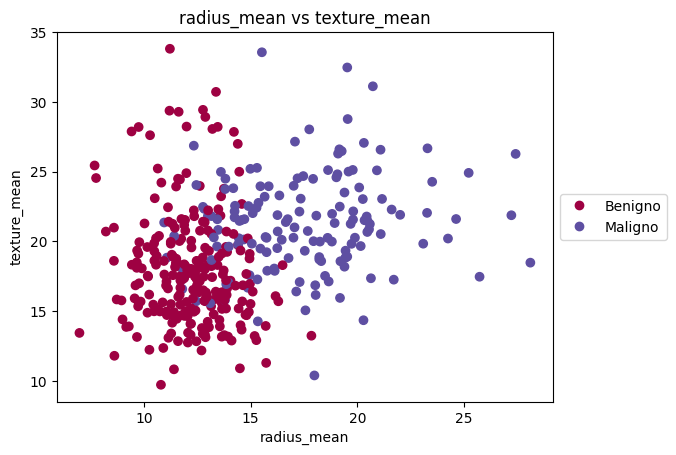

In [12]:
fig = plt.scatter(x_train['radius_mean'], x_train['texture_mean'], c=y_train, cmap=plt.cm.Spectral)
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.title('radius_mean vs texture_mean')

# legenda discreta de cores
handles, labels = fig.legend_elements(prop='colors')
plt.legend(handles, ['Benigno', 'Maligno'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

#### Visualização Raio x Diagnóstico

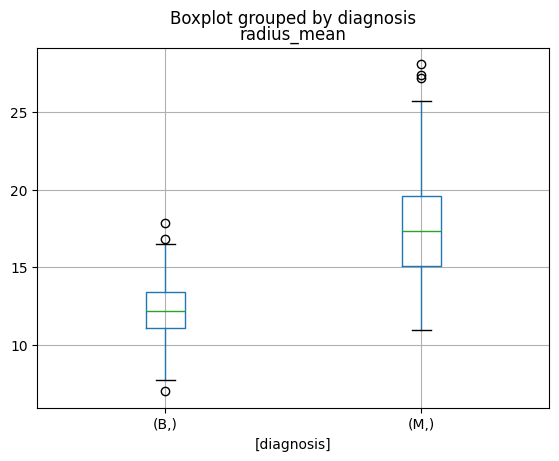

In [13]:
df1.boxplot(column=['radius_mean'], by=['diagnosis'])
plt.show()

## **Normalizando os Dados**

Etapa primordial pro treinamento de redes neurais:

- no melhor dos casos pode ser que a rede aprenda, mas vc estará dificultando a convergência do modelo!
- no pior dos casos, a rede não aprende, não converge.

In [14]:
x_train[0:2]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
911685,11.49,14.59,73.99,404.9,0.1046,0.08228,0.05308,0.01969,0.1779,0.06574,...,12.40,21.90,82.04,467.6,0.1352,0.2010,0.25960,0.07431,0.2941,0.09180
892657,10.49,18.61,66.86,334.3,0.1068,0.06678,0.02297,0.01780,0.1482,0.06600,...,11.06,24.54,70.76,375.4,0.1413,0.1044,0.08423,0.06528,0.2213,0.07842


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(x_train)
X_train_normalized = scaler.transform(x_train)
X_test_normalized = scaler.transform(x_test)

In [16]:
X_train_normalized[0:2]

array([[-0.74998027, -1.09978744, -0.74158608, -0.70188697,  0.58459276,
        -0.42772603, -0.45754987, -0.7605498 , -0.09986038,  0.45144364,
        -0.70061171, -0.06976187, -0.6167312 , -0.54340833, -0.70915256,
        -0.23548916,  0.36208998, -0.62177677, -0.24139043, -0.04596325,
        -0.7984831 , -0.591967  , -0.74660155, -0.71452908,  0.11632807,
        -0.34125524, -0.04627198, -0.6235968 ,  0.07754241,  0.45062841],
       [-1.02821446, -0.1392617 , -1.02980434, -0.89473179,  0.74288151,
        -0.73184316, -0.84330079, -0.80880455, -1.15975947,  0.48938568,
        -0.88760388,  0.65038093, -0.86919066, -0.62900544,  0.66188352,
        -0.93600214, -0.46060034, -0.42348318, -0.30503075, -0.15870653,
        -1.06870276, -0.16198127, -1.07434344, -0.86894147,  0.38200132,
        -0.97073687, -0.95489389, -0.7612376 , -1.07145262, -0.29541379]])

In [17]:
X_train_normalized.mean()

np.float64(2.5291512788780787e-18)

In [18]:
X_train_normalized.std()

np.float64(1.0)

# Rede Neural

In [19]:
from keras import Sequential
from keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

In [20]:
NumberOfClasses = len(np.unique(y_train))
NumberOfClasses

2

In [21]:
RN = Sequential()
RN.add(Input(X_train_normalized.shape[1:]))
RN.add(Dense(16, activation='sigmoid'))               # camada escondida
RN.add(Dense(NumberOfClasses, activation='sigmoid'))  # camada de saída
RN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530 (2.07 KB)

 Trainable params: 530 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
mc = ModelCheckpoint(filepath='best.h5', save_best_only=True)
es = EarlyStopping(patience=5)

In [23]:
# treinamento
from tensorflow.keras.utils import to_categorical
sgd = SGD(learning_rate=0.1, momentum=0.9)
RN.compile(optimizer=sgd, loss='mean_squared_error', metrics=['accuracy'])
history = RN.fit(X_train_normalized, to_categorical(y_train), epochs=100, validation_split=0.2, callbacks=[mc, es])  # treino a rede neural

Epoch 1/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 5s 652ms/step - accuracy: 0.5938 - loss: 0.2918

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6289 - loss: 0.2518 - val_accuracy: 0.6250 - val_loss: 0.2022
Epoch 2/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6875 - loss: 0.1765

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8113 - loss: 0.1478 - val_accuracy: 0.9125 - val_loss: 0.1191
Epoch 3/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9688 - loss: 0.0917

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9371 - loss: 0.0876 - val_accuracy: 0.9375 - val_loss: 0.0726
Epoch 4/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0427

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9465 - loss: 0.0566 - val_accuracy: 1.0000 - val_loss: 0.0518
Epoch 5/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9375 - loss: 0.0555

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9874 - loss: 0.0148 - val_accuracy: 0.9875 - val_loss: 0.0112
Epoch 75/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9874 - loss: 0.0148 - val_accuracy: 0.9875 - val_loss: 0.0113
Epoch 76/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9874 - loss: 0.0147 - val_accuracy: 0.9875 - val_loss: 0.0113
Epoch 77/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9874 - loss: 0.0147 - val_accuracy: 0.9875 - val_loss: 0.0112
Epoch 78/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0032

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9874 - loss: 0.0147 - val_accuracy: 0.9875 - val_loss: 0.0110
Epoch 79/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0075

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9874 - loss: 0.0146 - val_accuracy: 0.9875 - val_loss: 0.0110
Epoch 80/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9688 - loss: 0.0287

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9874 - loss: 0.0146 - val_accuracy: 0.9875 - val_loss: 0.0110
Epoch 81/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9874 - loss: 0.0145 - val_accuracy: 0.9875 - val_loss: 0.0110
Epoch 82/100
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0067

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9874 - loss: 0.0145 - val_accuracy: 0.9875 - val_loss: 0.0109
Epoch 83/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9874 - loss: 0.0145 - val_accuracy: 0.9875 - val_loss: 0.0110
Epoch 84/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9874 - loss: 0.0144 - val_accuracy: 0.9875 - val_loss: 0.0112
Epoch 85/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9874 - loss: 0.0144 - val_accuracy: 0.9875 - val_loss: 0.0112
Epoch 86/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9874 - loss: 0.0143 - val_accuracy: 0.9875 - val_loss: 0.0111
Epoch 87/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9874 - loss: 0.0143 - val_accuracy: 0.9875 - val_loss: 0.0111


In [24]:
# Usar o melhor modelo salvo em best.h5
RN.load_weights(filepath='best.h5')

In [25]:
score = RN.evaluate(X_test_normalized, to_categorical(y_test), verbose = 0)
print('Test score:', score[0])
print('Test accuracy:', score[1])

Test score: 0.02485988847911358
Test accuracy: 0.9649122953414917


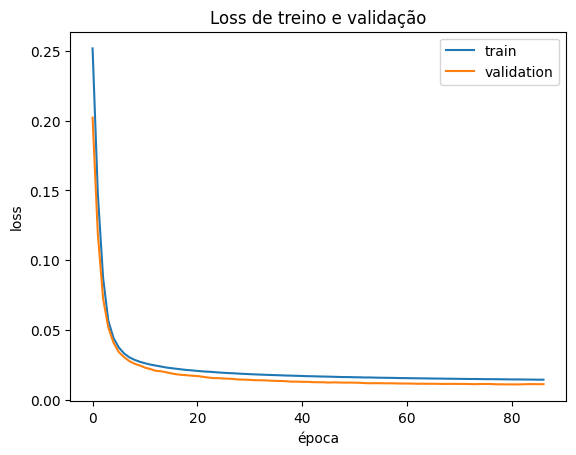

In [26]:
# Gráfico do treinamento: custo do treino e validação
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss de treino e validação')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend();

In [27]:
# Previsão
y_test_predicted = RN.predict(X_test_normalized)
y_test_predicted[0:3]

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([[0.00880549, 0.9888533 ],
       [0.9471357 , 0.04890827],
       [0.9923161 , 0.00760493]], dtype=float32)

In [28]:
y_test_predicted_indexes = np.argmax(y_test_predicted,axis=1)
y_test_predicted_indexes[0:3]

array([1, 0, 0])

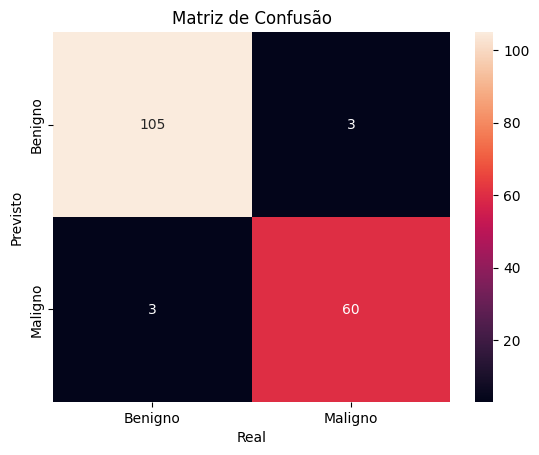

In [29]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
confMatrix = confusion_matrix(y_test_predicted_indexes, y_test)

ax = plt.subplot()
sns.heatmap(confMatrix, annot=True, fmt=".0f")
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.title('Matriz de Confusão')

# Colocar os nomes
ax.xaxis.set_ticklabels(['Benigno', 'Maligno'])
ax.yaxis.set_ticklabels(['Benigno', 'Maligno'])
plt.show()

##Pós processamento: vou ser mais conservadora olhando para as probabilidades
Se o modelo não me der 80% de certeza que se trata de um tumor benigno, eu classifico como maligno.

In [30]:
y_test_predicted[0:3]

array([[0.00880549, 0.9888533 ],
       [0.9471357 , 0.04890827],
       [0.9923161 , 0.00760493]], dtype=float32)

In [31]:
y_pred = []
for prediction in y_test_predicted:
  if prediction[0] < 0.8:
    y_pred.append(1)  # 'M'
  else:
    y_pred.append(0)  # 'B'

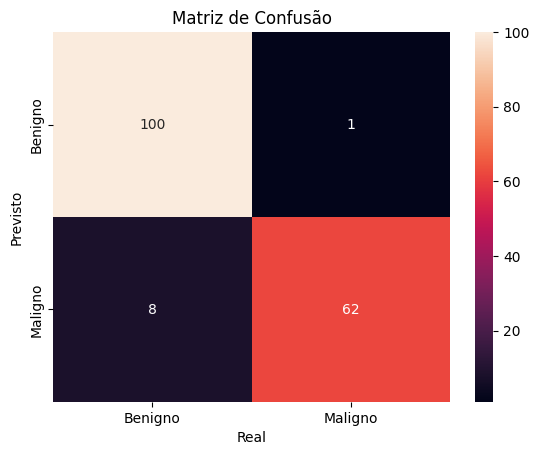

In [32]:
confMatrix = confusion_matrix(y_pred, y_test)

ax = plt.subplot()
sns.heatmap(confMatrix, annot=True, fmt=".0f")
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.title('Matriz de Confusão')

# Colocar os nomes
ax.xaxis.set_ticklabels(['Benigno', 'Maligno'])
ax.yaxis.set_ticklabels(['Benigno', 'Maligno'])
plt.show()

## Exportação dos artefatos para uso na API

Salvar o modelo treinado, o `scaler` (normalização dos atributos de entrada) e o `encoder` (decodificação da classe de saída) para serem carregados posteriormente pela API.

In [ ]:
import joblib

# salvar o scaler (StandardScaler) usado para normalizar os atributos de entrada
joblib.dump(scaler, 'scaler.pkl')

# salvar o encoder (LabelEncoder) usado para decodificar a classe de saída (0 = B, 1 = M)
joblib.dump(encoder, 'encoder.pkl')

# salvar o modelo treinado (já com os melhores pesos carregados na célula 34)
RN.save('model.keras')

In [ ]:
# baixar os arquivos do Colab para a máquina local
from google.colab import files

files.download('model.keras')
files.download('scaler.pkl')
files.download('encoder.pkl')